# Transfer Window Prediction Model with PySpark KNN and MapReduce

This notebook implements a K-Nearest Neighbors classifier with MapReduce for distributed transfer prediction using PySpark.

**Workflow:**
1. Load and preprocess raw data from Data folder
2. Create aggregated player features (last 3/6 seasons)
3. Prepare features and target variable
4. Implement PySpark KNN with MapReduce
5. Evaluate model performance

**For Kaggle:** Replace local paths with `/kaggle/input/` paths

In [28]:
%pip install pyspark
%pip install findspark
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Step 1: Environment Setup and Data Loading

In [29]:
import os
import re
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import findspark
findspark.init()


from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf, year, substring, avg, when
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Create SparkSession
spark = SparkSession.builder \
    .appName("Transfer_Prediction_KNN") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("✓ PySpark initialized successfully")

# ===== Data Path Configuration =====
DATA_DIR = '/kaggle/input/datasets/xfkzujqjvx97n/football-datasets'
OUTPUT_DIR = '/PreProcessedData'

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

START_SEASON = 2015
END_SEASON = 2026

datasets = {
    'player_profiles': f'{DATA_DIR}/player_profiles/player_profiles.csv',
    'transfer_history': f'{DATA_DIR}/transfer_history/transfer_history.csv',
    'player_performances': f'{DATA_DIR}/player_performances/player_performances.csv',
    'player_national_performances': f'{DATA_DIR}/player_national_performances/player_national_performances.csv',
    'player_injuries': f'{DATA_DIR}/player_injuries/player_injuries.csv',
}

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

✓ PySpark initialized successfully
Data directory: /kaggle/input/datasets/xfkzujqjvx97n/football-datasets
Output directory: /PreProcessedData


In [30]:
# ===== Preprocessing Functions (from preprocess_data.ipynb) =====
def is_date_column(col_name):
    date_keywords = ['date', 'day', 'dob', 'from', 'to', 'since', 'until', 'start', 'end']
    lower = col_name.lower()
    return any(keyword in lower for keyword in date_keywords)

def clean_string_series(series):
    return (
        series.astype(str)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

def coerce_numeric(series):
    cleaned = (
        series.astype(str)
        .str.replace(',', '', regex=False)
        .str.replace(r'[^0-9.+-]', '', regex=True)
    )
    return pd.to_numeric(cleaned, errors='coerce')

def extract_season_id_from_transfer_date(df):
    df = df.dropna(subset=['transfer_date'])
    df['season_id'] = df['transfer_date'].dt.year
    df.loc[df['transfer_date'].dt.month != 1, 'season_id'] += 1
    df['season_id'] = df['season_id'].astype(int)
    df = df[df['season_id'] >= START_SEASON]
    df = df[df['season_id'] <= END_SEASON]
    return df

def extract_seasonID_from_season_name(df):
    """Extract season year from season_name and filter to recent seasons"""
    season_raw = df['season_name'].astype('string').str.strip().dropna()
    season_pair = season_raw.str.extract(r'(?P<start>\d{2})[/-](?P<end>\d{2})')
    df['season_year'] = pd.to_numeric(season_pair['end'], errors='coerce') + 2000
    df = df.dropna(subset=['season_year'])
    df['season_year'] = df['season_year'].astype(int)
    df = df.drop(columns=['season_name'], errors='ignore')
    df = df[df['season_year'] >= START_SEASON]
    df = df[df['season_year'] <= END_SEASON]
    return df

def preprocess_table(name, path):
    """Load and preprocess each data table"""
    df = pd.read_csv(path)
    
    Columns = {
        'player_profiles': ['player_id', 'player_slug'],
        'transfer_history': ['player_id', 'transfer_date'],
        'player_performances': ['player_id', 'season_name', 'nb_in_group', 'nb_on_pitch', 'goals', 
                               'assists', 'own_goals', 'yellow_cards', 'second_yellow_cards', 
                               'direct_red_cards', 'penalty_goals', 'minutes_played', 
                               'goals_conceded', 'clean_sheets'],
        'player_national_performances': ['player_id', 'matches', 'goals'],
        'player_injuries': ['player_id', 'season_name', 'days_missed', 'games_missed']
    }
    
    # Select only required columns
    df = df[Columns.get(name, [])]
    
    # Fix data types: numeric strings and dates
    for col_name in df.columns:
        if df[col_name].dtype == 'object':
            if is_date_column(col_name):
                df[col_name] = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True)
            elif col_name == 'season_name':
                df[col_name] = clean_string_series(df[col_name])
            else:
                numeric_candidate = coerce_numeric(df[col_name])
                numeric_ratio = numeric_candidate.notna().mean()
                if numeric_ratio >= 0.7:
                    df[col_name] = numeric_candidate
                else:
                    df[col_name] = clean_string_series(df[col_name])
    
    # Apply special preprocessing
    if name == 'transfer_history':
        df = extract_season_id_from_transfer_date(df)
    elif name in ['player_performances', 'player_injuries']:
        df = extract_seasonID_from_season_name(df)
    
    # Save preprocessed data
    output_path = os.path.join(OUTPUT_DIR, name, f'{name}.csv')
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"✓ {name}: {len(df)} rows saved")
    
    return df

# Load and preprocess all datasets
dfs = {}
for name, path in datasets.items():
    if os.path.exists(path):
        dfs[name] = preprocess_table(name, path)
    else:
        print(f"⚠ Warning: {path} not found")

print("\n✓ All data loaded and preprocessed")

✓ player_profiles: 92671 rows saved
✓ transfer_history: 696244 rows saved
✓ player_performances: 1009064 rows saved
✓ player_national_performances: 92701 rows saved
✓ player_injuries: 122602 rows saved

✓ All data loaded and preprocessed


## Step 2: Feature Engineering

Create aggregated player features from historical performance and injury data for transfer prediction.

In [31]:
# Determine last season in transfer data
transfer_df = dfs['transfer_history'].copy()
player_perf_df = dfs['player_performances'].copy()

last_season = int(transfer_df['season_id'].max())
second_last_season = int(transfer_df['season_id'].unique()[-2]) if len(transfer_df['season_id'].unique()) > 1 else last_season - 1

print(f"Last season: {last_season}, Using season {second_last_season} for features")

# Create target: players who transferred in the last season
players_transferred_last_season = set(transfer_df[transfer_df['season_id'] == last_season]['player_id'].unique())

# Feature columns from different data sources
perf_feature_cols = [
    'nb_in_group', 'nb_on_pitch', 'goals', 'assists', 'own_goals', 
    'yellow_cards', 'second_yellow_cards', 'direct_red_cards', 
    'penalty_goals', 'minutes_played', 'goals_conceded', 'clean_sheets'
]
inj_feature_cols = ['days_missed', 'games_missed']
nat_feature_cols = ['matches', 'goals']

def aggregate_seasons(df, player_col, feature_cols, seasons, season_col='season_year'):
    df_f = df[df[season_col].isin(seasons)].copy()
    if df_f.empty:
        return pd.DataFrame(columns=[player_col])
    return df_f.groupby(player_col)[feature_cols].sum().reset_index()

# Last 3 and 6 seasons
last3_seasons = [second_last_season - i for i in range(3)]
last6_seasons = [second_last_season - i for i in range(6)]

# ===== PERFORMANCE FEATURES =====
perf_by_season = player_perf_df.groupby(['player_id', 'season_year'])[perf_feature_cols].sum().reset_index()

perf_last3 = aggregate_seasons(perf_by_season, 'player_id', perf_feature_cols, last3_seasons)
perf_last3.columns = ['player_id'] + [f'{col}_3yr' for col in perf_feature_cols]

perf_last6 = aggregate_seasons(perf_by_season, 'player_id', perf_feature_cols, last6_seasons)
perf_last6.columns = ['player_id'] + [f'{col}_6yr' for col in perf_feature_cols]

# ===== INJURIES FEATURES =====
inj_df = dfs['player_injuries'].copy()
inj_by_season = inj_df.groupby(['player_id', 'season_year'])[inj_feature_cols].sum().reset_index()

inj_last3 = aggregate_seasons(inj_by_season, 'player_id', inj_feature_cols, last3_seasons)
inj_last3.columns = ['player_id'] + [f'{col}_inj_3yr' for col in inj_feature_cols]

inj_last6 = aggregate_seasons(inj_by_season, 'player_id', inj_feature_cols, last6_seasons)
inj_last6.columns = ['player_id'] + [f'{col}_inj_6yr' for col in inj_feature_cols]

# ===== NATIONAL PERFORMANCE FEATURES =====
nat_perf_df = dfs['player_national_performances'].copy()
nat_perf_agg = nat_perf_df.groupby('player_id')[nat_feature_cols].sum().reset_index()
nat_perf_agg.columns = ['player_id'] + [f'{col}_nat' for col in nat_feature_cols]

# ===== MERGE ALL FEATURES ON player_id =====
X_df = perf_last3.merge(perf_last6, on='player_id', how='outer')
X_df = X_df.merge(inj_last3, on='player_id', how='outer')
X_df = X_df.merge(inj_last6, on='player_id', how='outer')
X_df = X_df.merge(nat_perf_agg, on='player_id', how='outer')
X_df = X_df.fillna(0)

# Create target
X_df['transferred'] = X_df['player_id'].isin(players_transferred_last_season).astype(int)

print(f"\n✓ Feature matrix shape: {X_df.shape}")
print(f"✓ Transfer rate: {X_df['transferred'].mean():.2%}")
print(f"✓ Transferred: {X_df['transferred'].sum()}, Non-transferred: {(1-X_df['transferred']).sum()}")
print(f"\nFeature categories:")
print(f"  - Performance: {len(perf_feature_cols)} * 2 windows = {len(perf_feature_cols)*2}")
print(f"  - Injuries: {len(inj_feature_cols)} * 2 windows = {len(inj_feature_cols)*2}")
print(f"  - National Performance: {len(nat_feature_cols)}")
print(f"  - Total features: {X_df.shape[1] - 2}")  # -2 for player_id and transferred

# Save to CSV for later use
X_df.to_csv(f'{OUTPUT_DIR}/model_features.csv', index=False)
print(f"✓ Features saved to {OUTPUT_DIR}/model_features.csv")

Last season: 2026, Using season 2017 for features

✓ Feature matrix shape: (56415, 32)
✓ Transfer rate: 28.49%
✓ Transferred: 16072, Non-transferred: 40343

Feature categories:
  - Performance: 12 * 2 windows = 24
  - Injuries: 2 * 2 windows = 4
  - National Performance: 2
  - Total features: 30
✓ Features saved to /PreProcessedData/model_features.csv


## Step 3: PySpark Data Preparation and Train-Test Split

In [32]:
# Feature engineering: aggregate performance & injuries across seasons
feature_cols = [
    'nb_in_group', 'nb_on_pitch', 'goals', 'assists', 'own_goals', 
    'yellow_cards', 'second_yellow_cards', 'direct_red_cards', 
    'penalty_goals', 'minutes_played', 'goals_conceded', 'clean_sheets'
]

# We'll build player-level features from historical seasons prior to the target (last_season)
perf_df = dfs['player_performances'].copy()
inj_df = dfs['player_injuries'].copy()

# Define target season boundaries
target_season = int(last_season)
feature_end_season = int(second_last_season)  # latest season allowed for features

# Helper to aggregate sums over a list of seasons
def aggregate_seasons_sum(df, seasons, cols, season_col='season_year'):
    df_f = df[df[season_col].isin(seasons)].copy()
    if df_f.empty:
        return pd.DataFrame(columns=['player_id'])
    agg = df_f.groupby('player_id')[cols].sum().reset_index()
    return agg

# Define windows (all windows end at feature_end_season to avoid leakage)
last3_prior = [feature_end_season - i for i in range(0, 3)]  # e.g., [2025,2024,2023]
last6_prior = [feature_end_season - i for i in range(0, 6)]  # last 6 seasons

# Aggregate performance sums
perf_by_season = perf_df.groupby(['player_id', 'season_year'])[feature_cols].sum().reset_index()

perf_last3 = aggregate_seasons_sum(perf_by_season, last3_prior, feature_cols)
perf_last3 = perf_last3.add_suffix('_last3')
perf_last3 = perf_last3.rename(columns={'player_id_last3': 'player_id'})

perf_last6 = aggregate_seasons_sum(perf_by_season, last6_prior, feature_cols)
perf_last6 = perf_last6.add_suffix('_last6')
perf_last6 = perf_last6.rename(columns={'player_id_last6': 'player_id'})

# Season-specific features for 2025 and 2026 (only include if <= feature_end_season)
season_specific_years = [2025, 2026]
season_feats = []
for yr in season_specific_years:
    col_prefix = f'season_{yr}'
    if yr <= feature_end_season:
        dfy = perf_by_season[perf_by_season['season_year'] == yr].copy()
        if not dfy.empty:
            agg = dfy.groupby('player_id')[feature_cols].sum().reset_index()
            agg = agg.add_prefix(col_prefix + '_')
            agg = agg.rename(columns={f'{col_prefix}_player_id': 'player_id'})
            season_feats.append(agg)
        else:
            # empty df placeholder
            season_feats.append(pd.DataFrame(columns=['player_id'] + [f'{col_prefix}_{c}' for c in feature_cols]))

# Aggregate injuries
inj_by_season = inj_df.groupby(['player_id', 'season_year'])[['days_missed', 'games_missed']].sum().reset_index()
inj_last3 = aggregate_seasons_sum(inj_by_season, last3_prior, ['days_missed', 'games_missed'])
inj_last3 = inj_last3.add_suffix('_last3').rename(columns={'player_id_last3': 'player_id'})
inj_last6 = aggregate_seasons_sum(inj_by_season, last6_prior, ['days_missed', 'games_missed'])
inj_last6 = inj_last6.add_suffix('_last6').rename(columns={'player_id_last6': 'player_id'})

# Merge all feature tables on player_id
dfs_to_merge = [perf_last3, perf_last6, inj_last3, inj_last6] + season_feats

from functools import reduce
def safe_merge(left, right):
    if left.empty:
        return right
    if right.empty:
        return left
    return pd.merge(left, right, on='player_id', how='outer')

features_merged = reduce(safe_merge, dfs_to_merge, pd.DataFrame(columns=['player_id']))
if features_merged.empty:
    raise RuntimeError('No aggregated features could be created — check season ranges and data')

# Fill missing numeric values with zeros
for c in features_merged.columns:
    if c != 'player_id':
        features_merged[c] = features_merged[c].fillna(0)

# Create final X and y aligned on player_id
X_df = features_merged.copy()
X_df = X_df.set_index('player_id')

# Target: whether player transferred in the target season
targets = pd.Series(0, index=X_df.index, name='transferred')
transferred_set = set(transfer_df[transfer_df['season_id'] == target_season]['player_id'].unique())
targets.loc[X_df.index.isin(transferred_set)] = 1

# Drop any players without features
valid_idx = ~X_df.isnull().any(axis=1)
X_df = X_df[valid_idx]
targets = targets[valid_idx]

X = X_df.reset_index(drop=True)
y = targets.reset_index(drop=True)

print(f"Aggregated feature matrix: {X.shape}")
print(f"Target vector: {y.shape}")

player_ids = features_merged['player_id'].values

print("Sample feature columns:")
print(X.columns[:20])


Aggregated feature matrix: (36347, 28)
Target vector: (36347,)
Sample feature columns:
Index(['nb_in_group_last3', 'nb_on_pitch_last3', 'goals_last3',
       'assists_last3', 'own_goals_last3', 'yellow_cards_last3',
       'second_yellow_cards_last3', 'direct_red_cards_last3',
       'penalty_goals_last3', 'minutes_played_last3', 'goals_conceded_last3',
       'clean_sheets_last3', 'nb_in_group_last6', 'nb_on_pitch_last6',
       'goals_last6', 'assists_last6', 'own_goals_last6', 'yellow_cards_last6',
       'second_yellow_cards_last6', 'direct_red_cards_last6'],
      dtype='object')


## 3. Normalization and Standardization

Apply both StandardScaler (z-score normalization) and MinMaxScaler (min-max normalization) for comparison.
StandardScaler centers data around 0 with unit variance.
MinMaxScaler scales features to [0, 1] range.


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from pyspark.storagelevel import StorageLevel

# Load features directly into Spark; do not convert to pandas here
features_df = spark.read.csv(f'{OUTPUT_DIR}/model_features.csv', header=True, inferSchema=True)
feature_cols = [c for c in features_df.columns if c not in ['player_id', 'transferred']]

# Collect rows once and build NumPy arrays from Spark data
feature_rows = features_df.select('player_id', 'transferred', *feature_cols).collect()
player_ids = [row['player_id'] for row in feature_rows]
X = np.array([[float(row[col]) for col in feature_cols] for row in feature_rows], dtype=float)
y = np.array([int(row['transferred']) for row in feature_rows], dtype=int)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (70-30)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y, range(len(X_scaled)), test_size=0.3, random_state=42, stratify=y
)

# Create DataFrames for PySpark
train_data = []
for i, (features, label) in enumerate(zip(X_train, y_train)):
    train_data.append((int(i), int(label), features.tolist()))

test_data = []
for i, (features, label) in enumerate(zip(X_test, y_test)):
    test_data.append((int(i), int(label), features.tolist()))

# Create Spark DataFrames
train_schema = "id INT, label INT, features ARRAY<DOUBLE>"
test_schema = "id INT, label INT, features ARRAY<DOUBLE>"

train_spark_df = spark.createDataFrame(train_data, schema=train_schema)
test_spark_df = spark.createDataFrame(test_data, schema=test_schema)

# Partition and cache training data for repeated KNN distance scans
train_rdd = train_spark_df.rdd.repartition(4).persist(StorageLevel.MEMORY_AND_DISK)
_ = train_rdd.count()  # materialize cache once

print(f"✓ Loaded Spark feature dataframe: {features_df.count()} rows, {len(feature_cols)} features")
print(f"✓ Train data: {train_rdd.count()} samples, partitions: {train_rdd.getNumPartitions()}")
print(f"✓ Test data: {test_spark_df.count()} samples")
print(f"✓ Feature dimension: {X_scaled.shape[1]}")

✓ Loaded Spark feature dataframe: 56415 rows, 30 features
✓ Train data: 39490 samples, partitions: 4
✓ Test data: 16925 samples
✓ Feature dimension: 30


# Transfer Prediction --> KNN using PySpark ML

## Feature Extraction and Preprocessing

We use the preprocessed and scaled features from the previous step.
The `X_train`, `X_test`, `y_train`, `y_test` arrays are already available from Step 3.
We convert them into Spark DataFrames using `VectorAssembler`-compatible format.

In [34]:
import pandas as pd
import numpy as np
from pyspark.ml.feature import VectorAssembler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from pyspark.sql import functions as F
import joblib

# X_train, X_test, y_train, y_test are already available from the preprocessing step
# They are StandardScaler-normalized NumPy arrays

# Further split X_test into val (20%) and test (10%) to match 70/20/10 split
X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_test, y_test, test_size=1/3, random_state=42, stratify=y_test
)

print(f"Train samples:      {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test_final)}")
print(f"Feature dimension:  {X_train.shape[1]}")

Train samples:      39490
Validation samples: 11283
Test samples:       5642
Feature dimension:  30


## Model Training


In [35]:
# Train sklearn KNN on the PySpark-preprocessed feature matrix
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

joblib.dump(knn, 'knn_transfer_model.pkl')
print("Model saved successfully as 'knn_transfer_model.pkl'")

Model saved successfully as 'knn_transfer_model.pkl'


## Model Testing


Model loaded successfully.
Val  Accuracy: 0.6408 | Val  F1: 0.2406
Test Accuracy: 0.6460 | Test F1: 0.2410


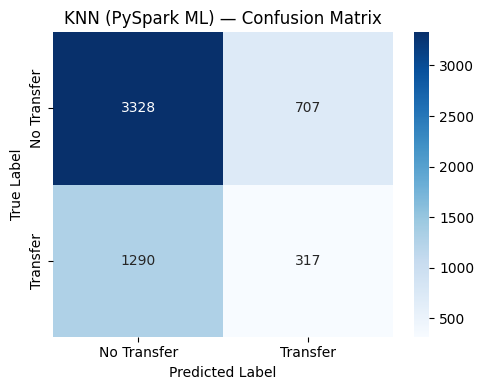


Classification Report:
              precision    recall  f1-score   support

 No Transfer       0.72      0.82      0.77      4035
    Transfer       0.31      0.20      0.24      1607

    accuracy                           0.65      5642
   macro avg       0.52      0.51      0.51      5642
weighted avg       0.60      0.65      0.62      5642



In [36]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

loaded_knn_model = joblib.load('knn_transfer_model.pkl')
print("Model loaded successfully.")

y_pred_val   = loaded_knn_model.predict(X_val)
y_pred_test  = loaded_knn_model.predict(X_test_final)

val_accuracy  = accuracy_score(y_val, y_pred_val)
test_accuracy = accuracy_score(y_test_final, y_pred_test)
val_f1        = f1_score(y_val, y_pred_val, zero_division=0)
test_f1       = f1_score(y_test_final, y_pred_test, zero_division=0)

print(f"Val  Accuracy: {val_accuracy:.4f} | Val  F1: {val_f1:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} | Test F1: {test_f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_final, y_pred_test)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Transfer', 'Transfer'],
            yticklabels=['No Transfer', 'Transfer'])
ax.set_title('KNN (PySpark ML) — Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('knn_pyspark_ml_confusion_matrix.png', dpi=100)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_final, y_pred_test, target_names=['No Transfer', 'Transfer']))

# KNN Implementation with Map Reduce

**Map Stage:**

Compute the k-nearest neighbours of each partition split.  
Output key-value pairs: `<None, (distance, label)>`

**Reduce Stage:**

The reducer combines partition-local neighbor lists and keeps the global top-K.  
Output the most frequent label of the K nearest neighbors.


## Feature Extraction and Preprocessing


In [37]:
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType
from math import sqrt
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from collections import Counter
from pyspark.ml import Pipeline
import numpy as np

# Re-use X_train, X_val, X_test_final, y_train, y_val, y_test_final from above.
# Limit to 1000 samples for the MapReduce KNN (computationally intensive)
LIMIT = 1000

X_train_mr = X_train[:LIMIT]
y_train_mr = y_train[:LIMIT]

X_val_mr   = X_val[:200]
y_val_mr   = y_val[:200]

X_test_mr  = X_test_final[:100]
y_test_mr  = y_test_final[:100]

# Convert to Spark RDDs
# Each row: (features_list, label)
train_data_list = [(X_train_mr[i].tolist(), int(y_train_mr[i])) for i in range(len(X_train_mr))]
val_data_list   = [(X_val_mr[i].tolist(),   int(y_val_mr[i]))   for i in range(len(X_val_mr))]
test_data_list  = [(X_test_mr[i].tolist(),  int(y_test_mr[i]))  for i in range(len(X_test_mr))]

train_rdd_mr = spark.sparkContext.parallelize(train_data_list).repartition(5)
val_rdd_mr   = spark.sparkContext.parallelize(val_data_list)
test_rdd_mr  = spark.sparkContext.parallelize(test_data_list)

train_rdd_mr = train_rdd_mr.repartition(5)
print(f"Train RDD partitions: {train_rdd_mr.getNumPartitions()}")
print(f"Train size: {len(train_data_list)} | Val size: {len(val_data_list)} | Test size: {len(test_data_list)}")

Train RDD partitions: 5
Train size: 1000 | Val size: 200 | Test size: 100


## Mapper and Reducer


In [38]:
import numpy as np
from pyspark.ml.linalg import DenseVector, SparseVector

def euclidean_distance(point1, point2):
    np1 = np.array(point1)
    np2 = np.array(point2)
    return float(np.linalg.norm(np1 - np2))

def KNN_map_reduce(rdd, test_point, k):
    """
    Map Stage:
      For each partition, compute distances from test_point to every training point.
      Emit (None, (distance, label)) pairs, keeping only the local top-k.

    Reduce Stage:
      Merge partition-local neighbor lists, keeping the global top-k.
      Classify by majority vote.
    """
    def mapper(partition):
        neighbors = []
        for row in partition:
            train_features = row[0]  # list of floats
            train_label    = row[1]  # int
            dist = euclidean_distance(train_features, test_point)
            neighbors.append((None, (dist, train_label)))
        neighbors.sort(key=lambda x: x[1][0])
        # Emit only local top-k to reduce shuffle size
        return [neighbors[:k]]

    def reducer(n1, n2):
        combined = n1 + n2
        combined.sort(key=lambda x: x[1][0])
        return combined[:k]

    def classify(neighbors):
        labels = [n[1][1] for n in neighbors]
        counts = {}
        for lbl in labels:
            counts[lbl] = counts.get(lbl, 0) + 1
        return max(counts.items(), key=lambda x: x[1])[0]

    neighbors_rdd = rdd.mapPartitions(mapper)
    if neighbors_rdd.isEmpty():
        return None
    top_k_neighbors = neighbors_rdd.reduce(reducer)
    return classify(top_k_neighbors)

## Model Training


In [39]:
# Predict for all val and test points using MapReduce KNN
k = 3

val_predictions  = []
for features, true_label in val_data_list:
    predicted_label = KNN_map_reduce(train_rdd_mr, features, k=k)
    val_predictions.append((predicted_label, true_label))

test_predictions = []
for features, true_label in test_data_list:
    predicted_label = KNN_map_reduce(train_rdd_mr, features, k=k)
    test_predictions.append((predicted_label, true_label))

## Model Testing


Val Accuracy: 0.6200
Test Accuracy: 0.6300

Val  F1: 0.2963
Test F1: 0.1395


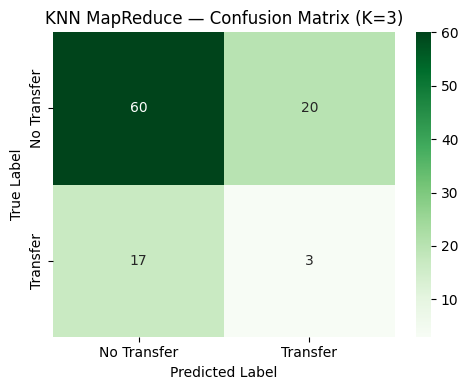


Classification Report:
              precision    recall  f1-score   support

 No Transfer       0.78      0.75      0.76        80
    Transfer       0.13      0.15      0.14        20

    accuracy                           0.63       100
   macro avg       0.45      0.45      0.45       100
weighted avg       0.65      0.63      0.64       100



In [40]:
from pyspark.sql.functions import when, avg as spark_avg
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Validation accuracy via Spark DataFrame ---
val_predictions_df = spark.createDataFrame(val_predictions, ["predicted_label", "true_label"])
val_accuracy_df = val_predictions_df.withColumn(
    "correct", when(col("predicted_label") == col("true_label"), 1).otherwise(0)
)
val_accuracy = val_accuracy_df.agg(spark_avg("correct")).collect()[0][0]
print(f"Val Accuracy: {val_accuracy:.4f}")

# --- Test accuracy via Spark DataFrame ---
test_predictions_df = spark.createDataFrame(test_predictions, ["predicted_label", "true_label"])
test_accuracy_df = test_predictions_df.withColumn(
    "correct", when(col("predicted_label") == col("true_label"), 1).otherwise(0)
)
test_accuracy = test_accuracy_df.agg(spark_avg("correct")).collect()[0][0]
print(f"Test Accuracy: {test_accuracy:.4f}")

# --- Detailed metrics using sklearn ---
y_val_true  = [p[1] for p in val_predictions]
y_val_pred  = [p[0] for p in val_predictions]
y_test_true = [p[1] for p in test_predictions]
y_test_pred = [p[0] for p in test_predictions]

print(f"\nVal  F1: {f1_score(y_val_true,  y_val_pred,  zero_division=0):.4f}")
print(f"Test F1: {f1_score(y_test_true, y_test_pred, zero_division=0):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_true, y_test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['No Transfer', 'Transfer'],
            yticklabels=['No Transfer', 'Transfer'])
ax.set_title(f'KNN MapReduce — Confusion Matrix (K={k})')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('knn_mapreduce_confusion_matrix.png', dpi=100)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_true, y_test_pred, target_names=['No Transfer', 'Transfer']))